**Experiment 9: Implement an Ensemble Learner using Random Forest Algorithm using python programming.**

**Aim:** To implement an ensemble learning model using the Random Forest algorithm for classification and evaluate its performance using appropriate metrics.

**Overview of Random Forest**

**Random Forest** is an **ensemble learning algorithm** used for **classification and regression**.
It builds multiple **decision trees** during training and combines their outputs to produce a more accurate and stable prediction.

Instead of relying on a single decision tree, Random Forest uses **many trees trained on random subsets of data and features**, and the final prediction is obtained by **majority voting (classification)** or **averaging (regression)**.

---

**Key Terms**

**1. Decision Tree (Base Learner)**

A **Decision Tree** is the basic model used in Random Forest.

Each tree learns patterns from the data and produces a prediction.

---

**2. Bootstrap Sampling**

Random Forest uses **Bootstrap Aggregating (Bagging)**.

From the original dataset with **N samples**, each tree is trained using a **random sample with replacement**.

D_t = BootstrapSample(D)

Where
(D) = original dataset
(D_t) = dataset used for tree (t)

---

**3. Random Feature Selection**

At each split of a tree, only a **random subset of features** is considered.

m = √p

Where
(p) = total number of features
(m) = number of randomly selected features.

---

**4. Information Gain (Split Criterion)**

Decision trees often use **Information Gain** based on entropy.

Entropy(S) = - Σ (p_i * log2(p_i))

Information Gain = Entropy(parent) - Σ ( |S_v| / |S| * Entropy(S_v) )

Where
(p_i) = probability of class (i).

---

**5. Gini Index (Alternative Split Criterion)**

Another measure used for node splitting.

Gini = 1 - Σ (p_i^2)

Lower Gini → better split.

---

**Final Prediction**

**Classification**

Final prediction is obtained using **majority voting**.

H(x) = mode{ h1(x), h2(x), ..., hT(x) }

Where
(h_t(x)) = prediction of tree (t)
(T) = total number of trees.

---

**Regression**

Prediction is the **average of outputs from all trees**.

H(x) = (1/T) Σ h_t(x)


**Mount Drive (Google Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [13]:
import pandas as pd

forest_data = pd.read_csv('drive/MyDrive/Datasets For ML/Forest Cover Type Prediction.csv')

print("Shape:", forest_data.shape)
print("Duplicated:", forest_data.duplicated().sum())
print("Null Values:", forest_data.isnull().sum().sum())
print("\nFirst 2 Rows:\n", forest_data.head(2))

Shape: (10000, 55)
Duplicated: 0
Null Values: 0

First 2 Rows:
       0    1   2    3   4     5    6    7    8     9  ...  45  46  47  48  49  \
0  2683  333  35   30  26  2743  121  173  179  6572  ...   0   0   0   0   0   
1  2915   90   8  216  11  4433  232  228  129  4019  ...   0   0   0   0   0   

   50  51  52  53  54  
0   0   0   0   0   2  
1   0   0   0   0   1  

[2 rows x 55 columns]


**Feature–Label Separation**

X → Features

Y → Class (Cover Type)

In [3]:
X, Y = forest_data.iloc[:, :-1], forest_data.iloc[:, -1]

**Train–Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (8000, 54)
X_test Shape: (2000, 54)


**Build Random Forest Model**

In [5]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [100, 200]
max_depth_list = [None, 10, 20]
max_features_list = ['sqrt', 'log2']
min_samples_split_list = [2, 5]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        for features in max_features_list:
            for min_split in min_samples_split_list:

                model = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    max_features=features,
                    min_samples_split=min_split,
                    bootstrap=True,
                    oob_score=True,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(X_train, Y_train)

                results.append([
                    n,
                    depth,
                    features,
                    min_split,
                    model.oob_score_
                ])

results_df = pd.DataFrame(results, columns=[
    "n_estimators",
    "max_depth",
    "max_features",
    "min_samples_split",
    "OOB_Score"
])

results_df.sort_values(by="OOB_Score", ascending=False).head()

,n_estimators,max_depth,max_features,min_samples_split,OOB_Score
12,200,NaN,sqrt,2,0.803625
14,200,NaN,log2,2,0.802375
0,100,NaN,sqrt,2,0.799125
13,200,NaN,sqrt,5,0.798000
1,100,NaN,sqrt,5,0.797125


**Select Best Model**

In [6]:
best_params = results_df.sort_values(by="OOB_Score", ascending=False).iloc[0]
best_params

,12
n_estimators,200
max_depth,NaN
max_features,sqrt
min_samples_split,2
OOB_Score,0.803625


**Train Final Model with Best Parameters**



In [7]:
max_depth_val = best_params['max_depth']
if pd.isna(max_depth_val):
    max_depth_for_model = None
else:
    max_depth_for_model = int(max_depth_val)

best_model = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=max_depth_for_model,
    max_features=best_params['max_features'],
    min_samples_split=int(best_params['min_samples_split']),
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, Y_train)

print("Best OOB Score:", best_model.oob_score_)

Best OOB Score: 0.803625


**Bias–Variance Insight**

In [8]:
train_accuracy = best_model.score(X_train, Y_train)
test_accuracy = best_model.score(X_test, Y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.7945


**Interpretation:**

If Train >> Test → Overfitting

If Train ≈ Test → Good Generalization

If both low → Underfitting

**Classification Output (Majority Voting)**

In [9]:
# Predict class labels
Y_pred = best_model.predict(X_test)

print("Sample Predictions (First 10):")
print(Y_pred[:10])

Sample Predictions (First 10):
[1 1 2 2 2 2 1 2 2 1]


Random Forest final output = most frequent class predicted by trees (mode).

**Class Probabilities (Confidence Levels)**

In [10]:
# Probability predictions
Y_prob = best_model.predict_proba(X_test)

print("Class Probabilities (First 5 Samples):")
print(Y_prob[:5])

Class Probabilities (First 5 Samples):
[[0.675 0.28  0.    0.    0.    0.    0.045]
 [0.5   0.5   0.    0.    0.    0.    0.   ]
 [0.06  0.65  0.035 0.    0.07  0.185 0.   ]
 [0.13  0.67  0.02  0.    0.145 0.035 0.   ]
 [0.43  0.485 0.015 0.    0.055 0.015 0.   ]]


**Each row represents:**

Probability of belonging to each cover type

Confidence = proportion of trees voting for that class

**Example interpretation:**
If output = [0.05, 0.90, 0.03, 0.02]
→ 90% trees voted for class 2.

**Feature Importance (Most Influential Variables)**

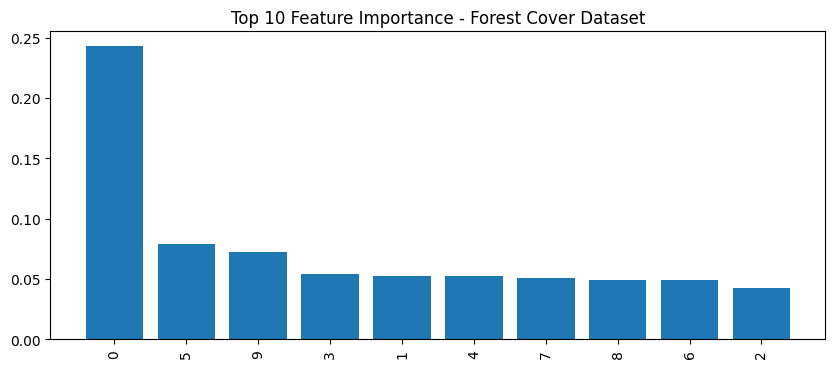

In [14]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
plt.title("Top 10 Feature Importance - Forest Cover Dataset")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X.columns[indices[:10]], rotation=90)
plt.show()

**Interpretation:** Higher score → Feature used more often in splitting → More influential.

**Model Evaluation**

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.7945

Confusion Matrix:

[[576 158   1   0   0   0   3]
 [137 825   8   0   1   4   0]
 [  0  13  99   0   0   6   0]
 [  0   0   4   4   0   2   0]
 [  1  26   0   0   6   0   0]
 [  0  11  20   0   0  29   0]
 [ 15   1   0   0   0   0  50]]

Classification Report:

              precision    recall  f1-score   support

           1       0.79      0.78      0.79       738
           2       0.80      0.85      0.82       975
           3       0.75      0.84      0.79       118
           4       1.00      0.40      0.57        10
           5       0.86      0.18      0.30        33
           6       0.71      0.48      0.57        60
           7       0.94      0.76      0.84        66

    accuracy                           0.79      2000
   macro avg       0.84      0.61      0.67      2000
weighted avg       0.80      0.79      0.79      2000



**Conclusion**

The Random Forest ensemble model was implemented for the forest cover type classification dataset. Multiple decision trees were trained using bootstrap sampling and random feature selection, and hyperparameters were tuned using the out-of-bag (OOB) score to select the best model. The final model achieved good accuracy on both training and testing data, indicating effective generalization. The results demonstrate that Random Forest improves classification performance by combining predictions from multiple decision trees using majority voting.
